# Pazy wing time-domain LCO

Perform a time-domain limit-cycle oscillation computation for the swept Pazy wing, plotting the deflection of the beam tip over time.

Imports

In [1]:
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt

from condor.aero.flowfields import Constant
from condor.models.pazy.swept.swept_pazy_wing import make_swept_pazy_wing

jax.config.update("jax_enable_x64", True)  # 64-bit required for structural analysis

Case parameters: freestream velocity, angle of attack, tip force/moment perturbation, and total physical simulation time.

In [2]:
# fig 23
q_inf = 960.0
model = "LE_CORRECTED"
alpha = jnp.deg2rad(10.0)  # angle of attack
physical_time = 1.5  # time to run the simulation for, in seconds

# fig 18a)
# q_inf = 3420.0
# model = "TE"
# alpha = jnp.deg2rad(7.0)  # angle of attack
# physical_time = 1.5  # time to run the simulation for, in seconds

# fig 18b)
# q_inf = 1800.0
# model = "LE_CORRECTED"
# alpha = jnp.deg2rad(1.0)  # angle of attack
# physical_time = 1.5  # time to run the simulation for, in seconds

u_inf_mag = jnp.sqrt(2.0 / 1.225 * q_inf)  # freestream velocity

# torsional moment to apply to the tip for the initial static solve. This leads to an overprediction in deformation compared to the actual aeroelastic equilbrium, giving the system an initial pertubation
m_tip = 2.0



Build the wing at the chosen freestream and AoA.

In [3]:
case = make_swept_pazy_wing(
    flowfield=Constant(
        u_inf=jnp.array((u_inf_mag, 0.0, 0.0)),
        rho=1.225,
        relative_motion=True,
    ),
    tip_mass=model,
    aoa=alpha,
    gravity=jnp.array((0.0, -9.81, 0.0)),
    m=8,
    # m=5,
    m_star=100,
    node_multiplier=1,
)

Time-step size is set by the aerodynamic panelling; derive the number of steps required for the requested physical time.

In [4]:
dt = case.aero.dt
n_tstep = int(physical_time / dt)
print(f"dt={float(dt):.4f} s, n_tstep={n_tstep}")

dt=0.0003 s, n_tstep=4750


Assemble the tip follower force / moment vector used to perturb the static solution.

In [5]:
f_ext = jnp.zeros((case.structure.n_nodes, 6)).at[-1, 3].set(m_tip)

Static equilibrium with the tip perturbation applied. This provides the initial condition for the time-domain solve.

In [6]:
# wing clamped at root
static_sol = case.static_solve(
    prescribed_dofs=tuple(range(6)), horseshoe=False, f_ext_follower=f_ext
)


+--------------------------------- Static Solve ----------------------------------+
|    Iter     | Conv  | Rel Disp  | Abs Disp  | Rel Force | Abs Force | Load Step |
+---------------------------------------------------------------------------------+

+--------------------------------- Static Solve ----------------------------------+
|    Iter     | Conv  | Rel Disp  | Abs Disp  | Rel Force | Abs Force | Load Step |
+---------------------------------------------------------------------------------+
+---------------------------------------------------------------------------------+
| Struct: 9   | True  | 1.276e-07 | 2.390e-07 | 4.725e-06 | 4.024e-04 | 0         |
| FSI: 1      | False | 1.000e+00 | 1.873e+00 | 3.288e+00 | 1.167e+01 |           |

+--------------------------------- Static Solve ----------------------------------+
|    Iter     | Conv  | Rel Disp  | Abs Disp  | Rel Force | Abs Force | Load Step |
+------------------------------------------------------------------------

Time-domain dynamic solve starting from the perturbed static equilibrium.

In [7]:
# initialise the dynamic solve with the static solution, prescribing the root DOFs to be fixed
dynamic_sol = case.dynamic_solve(
    init_case=static_sol, prescribed_dofs=tuple(range(6)), n_tstep=n_tstep
)


+-------------------------------------------- Dynamic Solve ---------------------------------------------+
| Timestep |   Time    |    Iter     | Conv  | Rel Disp  | Abs Disp  | Rel Force | Abs Force | Load Step |
+--------------------------------------------------------------------------------------------------------+
| 1        | 3.157e-04 | Struct: 3   | True  | 3.595e-07 | 2.483e-09 | 1.140e-03 | 9.485e-02 | 0         |
| 1        | 3.157e-04 | FSI: 1      | True  | 1.000e+00 | 6.909e-03 | 2.707e-15 | 8.592e-15 |           |
| 2        | 6.315e-04 | Struct: 2   | True  | 6.524e-08 | 3.399e-10 | 7.221e-04 | 6.236e-02 | 0         |
| 2        | 6.315e-04 | FSI: 2      | True  | 7.058e-04 | 3.677e-06 | 4.026e-02 | 1.278e-01 |           |
| 3        | 9.472e-04 | Struct: 2   | True  | 7.074e-08 | 3.585e-10 | 1.002e-03 | 8.103e-02 | 0         |
| 3        | 9.472e-04 | FSI: 2      | True  | 7.192e-04 | 3.645e-06 | 4.181e-02 | 1.328e-01 |           |
| 4        | 1.263e-03 | Struct: 2  

Uncomment to write files for visualisation in ParaView.

In [8]:
# dynamic_sol.plot("./out/")

Plot beam tip vertical deflection over time.

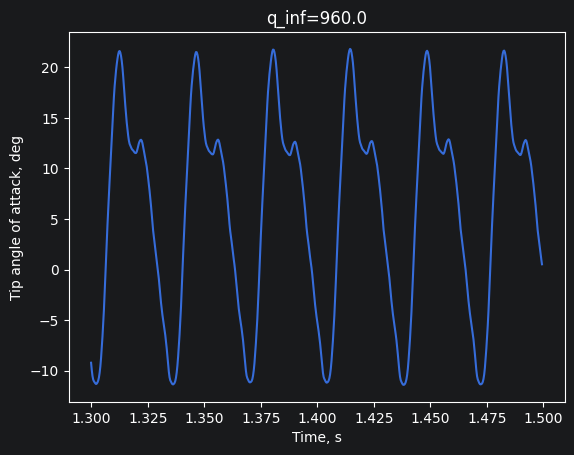

In [10]:
tip_norm = dynamic_sol.aero.nc[0][:, 0, -1, :]  # [n_tstep, 3]
tip_norm /= jnp.linalg.norm(tip_norm, axis=-1, keepdims=True)

tip_alpha = jnp.rad2deg(jnp.asin(-tip_norm[:, 0]))  # [n_tstep]
t = jnp.arange(n_tstep) * dt

t_plot_start = 1.3
i_ts_start = int(t_plot_start // dt)
fig, ax = plt.subplots()
ax.plot(t[i_ts_start:], tip_alpha[i_ts_start:])
ax.set_xlabel("Time, s")
ax.set_ylabel("Tip angle of attack, deg")
ax.set_title(f"q_inf={q_inf}")
plt.show()